# **Meeting Transcript Summarizer**

The workflow takes a meeting transcript and title, validates the input, generates a summary, checks it for quality, and formats a final report. If the input is too short to summarize meaningfully, the workflow ends early with an error note. If the generated summary does not meet the quality threshold, the workflow also ends early rather than delivering a poor output.

## **Step 1: Define the State**

In [1]:
from typing import TypedDict

class MeetingState(TypedDict):
    # Input — provided at invocation, never modified by nodes
    transcript: str
    meeting_title: str

    # Input validation and output quality validation
    input_valid: bool
    quality_passed: bool

    # Number of words in the output
    word_count: int

    # Output — written by drafting and finalization nodes
    raw_summary: str
    final_report: str
    error_note: str

## **Step 2: Setting up the Nodes**

### **The validation node**
The first node checks whether the input is worth processing. A transcript shorter than 30 words cannot produce a meaningful summary, so we catch that here rather than wasting a model call.

In [2]:
def validate_input(state: MeetingState) -> dict:
    transcript = state["transcript"].strip()
    word_count = len(transcript.split())
    if not state["meeting_title"].strip():
        return {
            "input_valid": False,
            "word_count": word_count,
            "error_note": "Meeting title is missing.",
        }
    if word_count < 30:
        return {
            "input_valid": False,
            "word_count": word_count,
            "error_note": f"Transcript too short ({word_count} words). Minimum is 30.",
        }
    return {"input_valid": True, "word_count": word_count, "error_note": ""}

### **The drafting node**
The drafting node is the only one that calls the large language model. It runs only if validation passed, so by the time it executes we know the transcript is long enough to summarize.

The Problem with "Defining Chat Models and Prompts Inside Nodes"

- **Object Re-instantiation Overhead:** If your graph loops 10 times, you are re-initializing the LLM client (including authentication, connection pooling, and configuration validation) 10 times. This adds unnecessary latency to every node execution.
- **Memory Bloat:** Each instance of a model or template consumes memory. In a high-concurrency production environment where multiple threads are executing concurrently, you could quickly exhaust your container's memory by constantly creating new objects.

In [12]:
from langchain_core.runnables import RunnableConfig

def draft_summary(state: MeetingState, config: RunnableConfig) -> dict:
    # Use LCEL to chain prompt + model cleanly
    model = config["configurable"]["model"]
    prompt = config["configurable"]["summary_prompt"]
    
    chain = prompt | model
    
    # Invocation
    response = chain.invoke({
        "meeting_title": state['meeting_title'],
        "transcript": state['transcript']
    })
    
    return {"raw_summary": response.content}

### **The output quality check node**

The quality check reads the raw summary and sets the quality_passed flag. Separating this from the drafting node keeps each node’s responsibility narrow, and makes it easy to adjust the quality criteria later without touching the generation logic.

In [7]:
def check_quality(state: MeetingState) -> dict:
    summary = state["raw_summary"].strip()
    word_count = len(summary.split())
    has_content = word_count >= 20
    is_not_empty = len(summary) >= 60
    return {"quality_passed": has_content and is_not_empty}

### **The finalization node**
The finalization node takes the raw summary and wraps it in a formatted report. This is output shaping: the work of turning generated text into something ready for delivery. It reads from multiple state fields and produces the single field `final_report`.

In [8]:
def finalize_summary(state: MeetingState) -> dict:
    header = (
        f"MEETING SUMMARY\n"
        f"{'=' * 40}\n"
        f"Title     : {state['meeting_title']}\n"
        f"Word count: {state['word_count']} words in transcript\n"
        f"{'=' * 40}\n\n"
    )
    body = state["raw_summary"].strip()
    final_report = header + body
    return {"final_report": final_report}

## **Step 3: Building the Workflow**

### **Defining Routing functions**
Two routing functions handle the conditional branches. Each reads one control field and returns a node name.

In [9]:
from typing import Literal

def route_after_validation(
    state: MeetingState,
) -> Literal["draft_summary", "__end__"]:
    return "draft_summary" if state["input_valid"] else "__end__"

def route_after_quality(
    state: MeetingState,
) -> Literal["finalize_summary", "__end__"]:
    return "finalize_summary" if state["quality_passed"] else "__end__"

### **Graph assembly**
Now we assemble the full graph:

In [10]:
from langgraph.graph import END, START, StateGraph

def build_graph():
    graph = StateGraph(MeetingState)
    graph.add_node("validate_input", validate_input)
    graph.add_node("draft_summary", draft_summary)
    graph.add_node("check_quality", check_quality)
    graph.add_node("finalize_summary", finalize_summary)

    graph.add_edge(START, "validate_input")
    graph.add_conditional_edges("validate_input", route_after_validation)
    graph.add_edge("draft_summary", "check_quality")
    graph.add_conditional_edges("check_quality", route_after_quality)
    graph.add_edge("finalize_summary", END)

    return graph.compile()

In [13]:
workflow = build_graph()

## **Step 4: Visualizing the Graph**

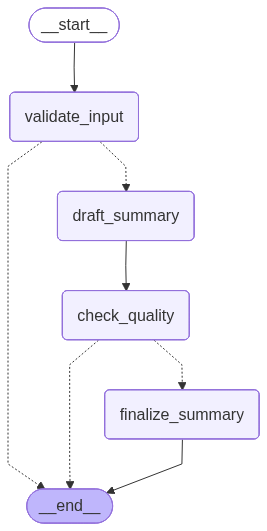

In [14]:
# Visualize the Graph
from IPython.display import Image, display

display(Image(workflow.get_graph(xray=True).draw_mermaid_png()))

## **Step 5: Running the Workflow**

### **Initializing the Prompts**

In [19]:
from langchain_core.prompts import ChatPromptTemplate

summary_prompt = ChatPromptTemplate(
    messages= [
        ("system", "You are an expert meeting summarizer."),
        ("human", 
         "Summarize the meeting '{meeting_title}' in 4-6 sentences covering:\n"
         "- Main topics\n- Decisions\n- Action items\n\n"
         "Notes:\n{transcript}"), 
    ]
)

### **Initializing the Chat Models**

In [20]:
from langchain_groq import ChatGroq

with open("keys/.groq_api_key.txt") as f:
    GROQ_API_KEY = f.read()

groq_chat_model = ChatGroq(
    api_key=GROQ_API_KEY, 
    model="openai/gpt-oss-120b", 
    temperature=1
)

groq_chat_model.invoke("hi").content

'Hello! How can I assist you today?'

### **Defining the Test Cases**

In [18]:
cases = [
    {
        "label": "Too short",
        "meeting_title": "Quick Sync",
        "transcript": "We discussed the project briefly.",
    },
    {
        "label": "Missing title",
        "meeting_title": "",
        "transcript": (
            "Long transcript about budget planning and resource allocation for the next quarter. "
            "Multiple decisions were made and action items assigned to team members."
        ),
    },
    {
        "label": "Valid transcript",
        "meeting_title": "Q3 Planning Session",
        "transcript": (
            "We opened by reviewing Q2 results. Revenue hit target at 4.2M. "
            "Sarah raised concerns about rising customer acquisition costs, up 15% QoQ. "
            "The team agreed to audit the marketing budget by end of month. "
            "Tom will lead the audit and present findings at the next all-hands. "
            "We also discussed the planned API migration. Engineering estimates four weeks. "
            "Decision: migration starts next sprint. No other blockers raised."
        ),
    },
]

### **Invoking the Workflow**

In [21]:
print("=== Meeting notes summarizer ===\n")
for case in cases:
    result = workflow.invoke({
        "transcript": case["transcript"],
        "meeting_title": case["meeting_title"],
        "input_valid": False,
        "quality_passed": False,
        "word_count": 0,
        "raw_summary": "",
        "final_report": "",
        "error_note": "",
    }, config={
        "configurable": {
            "model": groq_chat_model,
            "summary_prompt": summary_prompt
        }
    })
    print(f"--- {case['label']} ---")
    if result["final_report"]:
        print(result["final_report"])
    else:
        print(f"Workflow exited early. Error: {result['error_note']}")
    print()

=== Meeting notes summarizer ===

--- Too short ---
Workflow exited early. Error: Transcript too short (5 words). Minimum is 30.

--- Missing title ---
Workflow exited early. Error: Meeting title is missing.

--- Valid transcript ---
MEETING SUMMARY
Title     : Q3 Planning Session
Word count: 66 words in transcript

The Q3 Planning Session opened with a review of Q2 results, confirming that revenue met the target of $4.2 M. Sarah highlighted a 15 % QoQ rise in customer‑acquisition costs, prompting the team to agree on a full audit of the marketing budget to be completed by month‑end. Tom was assigned to lead that audit and will present his findings at the next all‑hands meeting. The group then moved to the planned API migration, with engineering estimating a four‑week effort. It was decided that the migration will kick off in the next sprint, and no additional blockers were identified.

